## Model 1 Choice Rationale
- Logistic Regression — interpretable baseline, handles high-dimensional sparse TF-IDF well, coefficients can show which words drive each effectiveness class
- Linear SVM (LinearSVC) — often performs strongly on text classification with TF-IDF, tends to handle class boundaries well in high-dimensional space

### Load Data

In [9]:
import scipy.sparse as sp
import pandas as pd
import pickle

# Load TF-IDF matrices
X_train_tfidf = sp.load_npz('../data/processed/X_train_tfidf.npz')
X_test_tfidf = sp.load_npz('../data/processed/X_test_tfidf.npz')

# Load labels
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Load Vectorizer
tfidf_vectorizer = pickle.load(open('../data/processed/tfidf_vectorizer.pkl', 'rb'))

### Model 1a: Train Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score


log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_tfidf, y_train)

y_pred_lr = log_reg.predict(X_test_tfidf)

print("=" * 55)
print("LOGISTIC REGRESSION - RESULTS")
print("=" * 55)
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("Macro F1-score:", round(f1_score(y_test, y_pred_lr, average='macro'), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION - RESULTS
Accuracy: 0.4728
Macro F1-score: 0.4317

Classification Report:

                        precision    recall  f1-score   support

Considerably Effective       0.44      0.41      0.42       310
      Highly Effective       0.61      0.58      0.59       411
           Ineffective       0.49      0.60      0.54        78
  Marginally Effective       0.25      0.28      0.27        74
  Moderately Effective       0.31      0.35      0.33       157

              accuracy                           0.47      1030
             macro avg       0.42      0.44      0.43      1030
          weighted avg       0.48      0.47      0.47      1030



### Model 1b: Train Linear SVM

In [11]:
from sklearn.svm import LinearSVC

svm_clf = LinearSVC(
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

svm_clf.fit(X_train_tfidf, y_train)

y_pred_svm = svm_clf.predict(X_test_tfidf)

print("=" * 55)
print("LINEAR SVM - RESULTS")
print("=" * 55)
print("Accuracy:", round(accuracy_score(y_test, y_pred_svm), 4))
print("Macro F1-score:", round(f1_score(y_test, y_pred_svm, average='macro'), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

LINEAR SVM - RESULTS
Accuracy: 0.4544
Macro F1-score: 0.3978

Classification Report:

                        precision    recall  f1-score   support

Considerably Effective       0.40      0.37      0.39       310
      Highly Effective       0.56      0.61      0.59       411
           Ineffective       0.47      0.51      0.49        78
  Marginally Effective       0.23      0.22      0.22        74
  Moderately Effective       0.32      0.29      0.31       157

              accuracy                           0.45      1030
             macro avg       0.40      0.40      0.40      1030
          weighted avg       0.45      0.45      0.45      1030



### Baseline: Majority Class Classifier

In [12]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train_tfidf, y_train)
y_pred_dummy = dummy_clf.predict(X_test_tfidf)

print("=" * 55)
print("BASELINE (MAJORITY CLASS) - RESULTS")
print("=" * 55)
print("Accuracy:", round(accuracy_score(y_test, y_pred_dummy), 4))
print("Macro F1-score:", round(f1_score(y_test, y_pred_dummy, average='macro'), 4))

BASELINE (MAJORITY CLASS) - RESULTS
Accuracy: 0.399
Macro F1-score: 0.1141


### Confusion Matrices (Visual Comparison)

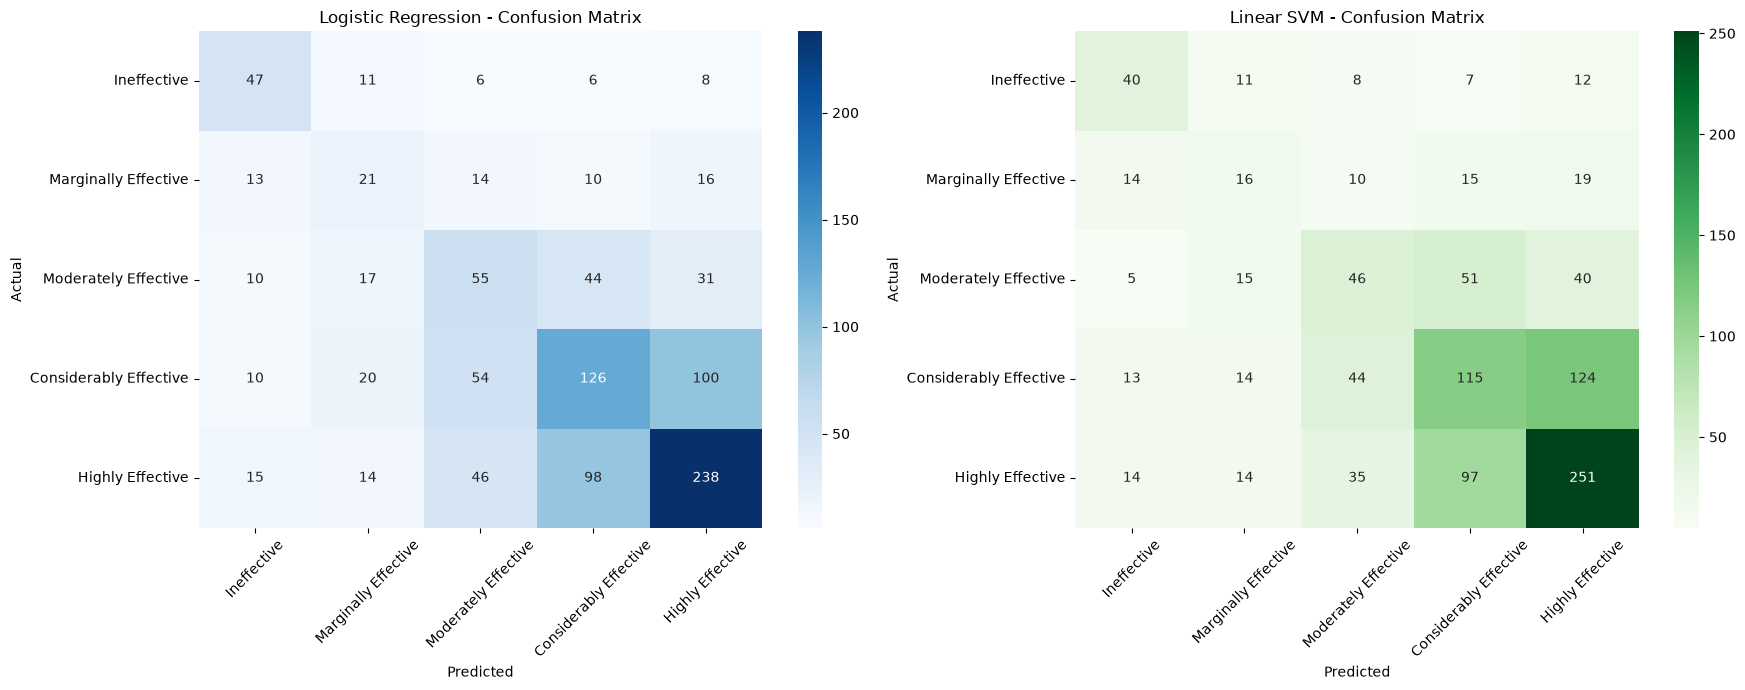

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sn
import matplotlib.pyplot as plt

labels_order = ['Ineffective', 'Marginally Effective', 'Moderately Effective', 
                 'Considerably Effective', 'Highly Effective']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cm_lr = confusion_matrix(y_test, y_pred_lr, labels=labels_order)
sn.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
           xticklabels=labels_order, yticklabels=labels_order, ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=labels_order)
sn.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', 
           xticklabels=labels_order, yticklabels=labels_order, ax=axes[1])
axes[1].set_title('Linear SVM - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../visuals/model1_confusion_matrices.png', dpi=150)
plt.show()

### Feature Importance — Top Words per Class (Logistic Regression Interpretability)

In [15]:
import numpy as np

feature_names = tfidf_vectorizer.get_feature_names_out()

for i, class_label in enumerate(log_reg.classes_):
    top_indices = np.argsort(log_reg.coef_[i])[-10:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    print(f"\n{class_label}:")
    print(", ".join(top_words))


Considerably Effective:
able, significantly, feeling, also, infection cleared, energy, considerably, reduce, eyelash, work well

Highly Effective:
within, year, pregnancy, life, almost, normal, immediate, extremely, completely, longer

Ineffective:
none, benefit, not, treat, antibiotic, nothing, whatsoever, saw, not benefit, amoxicillin

Marginally Effective:
improvement, slightly, benefit, not much, slight improvement, supposed, head, marginal, believe, far

Moderately Effective:
moderate, reduced, event, moderately, redness, lessened, helped, though, without, skin
